In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3  # 上下文长度: 表示用多少个字符来预测下一个字符
X, Y = [], []
for w in words[:5]:

    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(f'{''.join(itos[i] for i in context)} ---> {ch}')
        context = context[1:] + [ix]  # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [7]:
# 查找表, 可以看作神经网络的第一层, 将 27 维表示的字母降到 2 维
C = torch.randn((27, 2))

In [8]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [9]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [10]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [11]:
h

tensor([[ 0.5566, -0.5010, -0.6141,  ...,  0.9098,  0.6549, -0.6085],
        [ 0.9350, -0.8304, -0.9890,  ..., -0.5855, -0.3018, -0.6740],
        [-0.0503, -0.4875, -0.6248,  ..., -0.6556, -0.3249, -0.9462],
        ...,
        [ 1.0000, -0.9957, -0.9996,  ...,  0.8486, -0.0727, -0.9998],
        [-0.4991,  0.0829, -0.9713,  ...,  0.9534,  0.2783, -0.9987],
        [ 0.8782, -0.8704, -0.9985,  ..., -0.9965, -0.5129, -0.3259]])

In [12]:
h.shape

torch.Size([32, 100])

In [13]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [14]:
logits = h @ W2 + b2

In [15]:
logits.shape

torch.Size([32, 27])

In [16]:
counts = logits.exp()

In [17]:
probs = counts / counts.sum(1, keepdim=True)

In [18]:
probs.shape

torch.Size([32, 27])

In [19]:
loss = -probs[torch.arange(32), Y].log().mean()
loss

tensor(17.8185)

In [20]:
# ========== now made respectable ==========

In [21]:
# build the dataset

block_size = 3  # 上下文长度: 表示用多少个字符来预测下一个字符
X, Y = [], []
for w in words:

    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]  # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [22]:
X.shape, Y.shape  # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [33]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True
sum(p.nelement() for p in parameters) # 总参数

3481

In [25]:
# 确定学习率
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [26]:
lri = []
lossi = []

for i in range(1000):
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    # counts = logits.exp()  # 等价于之前统计的 N 矩阵
    # probs = counts / counts.sum(1, keepdim=True)
    # loss = -probs[torch.arange(32), Y].log().mean()
    # print(loss.item())

    # 等价于上面
    # 使用 pytorch 内置的交叉熵函数, 前向传播的效率可以大幅提升, 后向的传播的效率也可以大幅提升
    # 同时能提高数值稳定性, 如果 logits 中有过大的正数, e^n 可能超过上限, pytorch 会先减去最大的正数
    loss = F.cross_entropy(logits, Y[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())

print(loss.item())

7.594258785247803


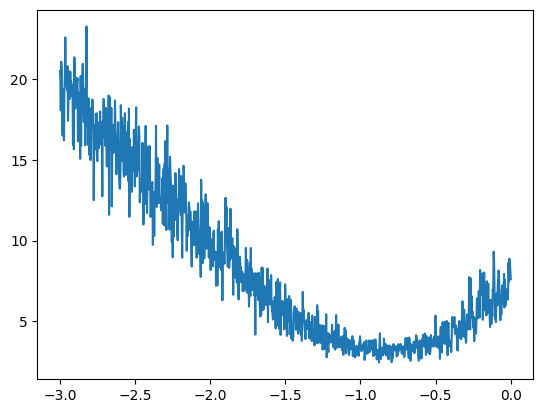

In [27]:
plt.plot(lri, lossi)

In [28]:
emb = C[X]  # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (228146, 100)
logits = h @ W2 + b2  # (228146, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(7.9101, grad_fn=<NllLossBackward0>)

In [29]:
# 训练时取学习率 10^(-1) 0.1, 训练到后期学习率可以取 0.01

In [30]:
# ========== 训练集/验证集/测试集 ==========

In [32]:
# build the dataset

import random


def build_dataset(words):
    block_size = 3  # 上下文长度: 表示用多少个字符来预测下一个字符
    X, Y = [], []
    for w in words:

        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [73]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True
sum(p.nelement() for p in parameters) # 总参数

11897

In [74]:
lossi = []
stepi = []

for i in range(200000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 2) -> (32, 3, 10)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 200)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    stepi.append(i)
    lossi.append(loss.log10().item())


# print(loss.item())

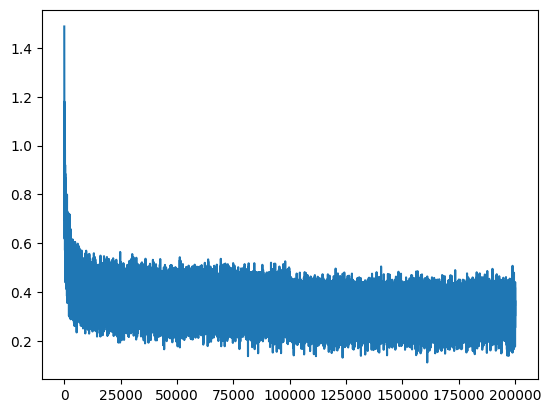

In [75]:
plt.plot(stepi, lossi)

In [76]:
emb = C[Xtr]  # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (228146, 100)
logits = h @ W2 + b2  # (228146, 27)
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

emb = C[Xdev]  # (228146, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (228146, 100)
logits = h @ W2 + b2  # (228146, 27)
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.1156647205352783
2.152146577835083


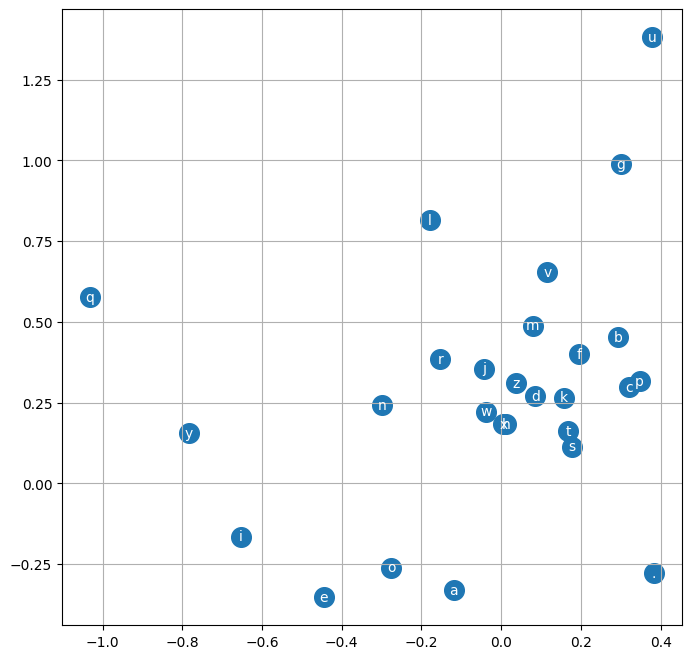

In [56]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

In [77]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carmahela.
jhavi.
kimrix.
taty.
skanden.
jazhnen.
delyah.
jareei.
nellara.
chaiir.
kaleigh.
ham.
pora.
quinn.
shon.
emira.
bico.
jero.
dearynix.
kaelynn.
